Setting up data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
path = '/content/drive/MyDrive/bccd'

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator , load_img

Library setup

In [9]:
import tensorflow as tf
import numpy as np
from tensorflow import keras
from keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D
from keras.applications.vgg16 import VGG16

Transfer learning

In [10]:
conv_base = VGG16(
    weights = 'imagenet',
    include_top = False,
    input_shape = (224,224,3),

)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [52]:
model = Sequential()

model.add(conv_base)
model.add(Flatten())
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       802,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,517,569 (59.19 MB)

 Trainable params: 15,517,569 (59.19 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
batch_size = 16

train_datagen = ImageDataGenerator(
    rescale = 1./255,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True
)

test_datagen = ImageDataGenerator(rescale = 1./255)

train_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/bccd/train',
    target_size = (224,224),
    batch_size = batch_size,
    class_mode = 'binary'
)

validate_generator = test_datagen.flow_from_directory(
    '/content/drive/MyDrive/bccd/train',
    target_size = (224,224),
    batch_size = batch_size,
    class_mode = 'binary'
)

Found 205 images belonging to 2 classes.
Found 205 images belonging to 2 classes.


In [34]:
from keras.utils import image_dataset_from_directory

In [ ]:
# generators
train_ds = image_dataset_from_directory(
    directory = '/content/drive/MyDrive/bccd/train',
    labels = 'inferred',
    # label_mode = 'binary',
    batch_size = batch_size,
    image_size = (224,224),
    shuffle = True
)


validate_ds = image_dataset_from_directory(
    directory = '/content/drive/MyDrive/bccd/val',
    labels = 'inferred',
    # label_mode = 'binary',
    batch_size = batch_size,
    image_size = (224,224),
    shuffle = True
)

Found 205 files belonging to 2 classes.
Found 87 files belonging to 2 classes.


Normalize pixels

In [36]:
def preprocess(image, label):
  image = tf.cast(image/255., tf.float32)
  return image, label

  train_ds = train_ds.map(preprocess)
  validate_ds = validate_ds.map(preprocess)

Training

In [53]:
model.compile(optimizer='adam',
              loss = 'binary_crossentropy',
              metrics= ['accuracy', 'precision', 'recall'])

In [31]:
model.fit(train_generator,
          validation_data=validate_generator,
          epochs=10)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5714 - loss: 0.0000e+00 - precision: 0.7901 - recall: 1.0000

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/losses/losses.py:33: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 139s 6s/step - accuracy: 0.5632 - loss: 0.0000e+00 - precision: 0.8022 - recall: 1.0000 - val_accuracy: 0.5632 - val_loss: 0.0000e+00 - val_precision: 0.8022 - val_recall: 1.0000
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 451ms/step - accuracy: 0.5632 - loss: 0.0000e+00 - precision: 0.8022 - recall: 1.0000 - val_accuracy: 0.5632 - val_loss: 0.0000e+00 - val_precision: 0.8022 - val_recall: 1.0000
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 424ms/step - accuracy: 0.5632 - loss: 0.0000e+00 - precision: 0.8022 - recall: 1.0000 - val_accuracy: 0.5632 - val_loss: 0.0000e+00 - val_precision: 0.8022 - val_recall: 1.0000
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 431ms/step - accuracy: 0.5632 - loss: 0.0000e+00 - precision: 0.8022 - recall: 1.0000 - val_accuracy: 0.5632 - val_loss: 0.0000e+00 - val_precision: 0.8022 - val_recall: 1.0000
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 450ms/step - accuracy: 0.5632 - loss: 0.0000e+00 - precision: 0.8022 - recall: 1.0000 - val_acc

Prediction

In [38]:
import cv2
import matplotlib.pyplot as plt

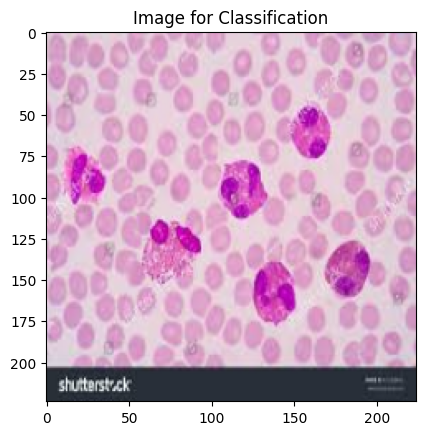

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
Prediction: [[2.8322859e-06]]
This image is likely eosinophil (e.g., Negative)


In [64]:
img = cv2.imread('/content/eosinophil blood cell image.jpg')
img = cv2.resize(img, (224,224))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.title('Image for Classification')
plt.show()

input_data = img.reshape((1,224,224,3))

prediction_result = model.predict(input_data)
print(f"Prediction: {prediction_result}")

if prediction_result > 0.5:
    print("This image is likely class 1 (e.g., Positive)")
else:
    print("This image is likely eosinophil (e.g., Negative)")

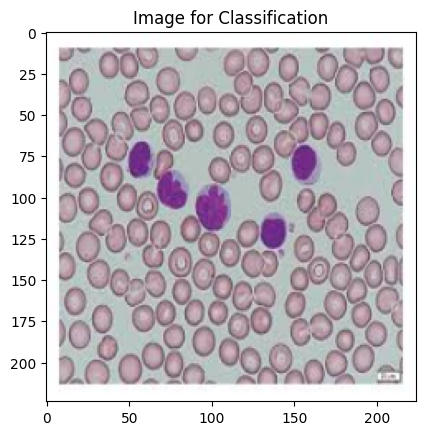

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Prediction: [[0.00415093]]
This image is likely lymphocyte (e.g., Negative)


In [65]:
img1 = cv2.imread('/content/lymphocyte microscope image.jpg')
img1 = cv2.resize(img1, (224,224))
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
plt.imshow(img1)
plt.title('Image for Classification')
plt.show()

input_data = img1.reshape((1,224,224,3))

prediction_result = model.predict(input_data)
print(f"Prediction: {prediction_result}")

if prediction_result > 0.5:
    print("This image is likely class 1 (e.g., Positive)")
else:
    print("This image is likely lymphocyte (e.g., Negative)")

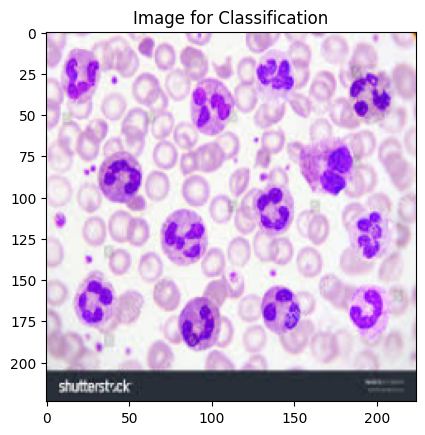

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Prediction for the third image: [[2.7898598e-06]]
This image is likely nutrophil (e.g., Negative)


In [66]:
img2 = cv2.imread('/content/neutrophil blood smear image.jpg')
img2 = cv2.resize(img2, (224, 224))
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

plt.imshow(img2)
plt.title('Image for Classification')
plt.show()

input_data = img2.reshape((1, 224, 224, 3))
prediction_result = model.predict(input_data)
print(f"Prediction for the third image: {prediction_result}")

if prediction_result > 0.5:
    print("This image is likely class 1 (e.g., Positive)")
else:
    print("This image is likely nutrophil (e.g., Negative)")